In [1]:
from google.colab import files
uploaded = files.upload()


Saving df_clean.csv to df_clean.csv


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('df_clean.csv')

X = df.drop(columns=['IC50, mM', 'CC50, mM', 'SI'])
y = np.log1p(df['CC50, mM'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print('LinearRegression R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))

LinearRegression R2: 0.379 RMSE: 1.188


In [4]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge()
ridge.fit(X_train, y_train)
pred = ridge.predict(X_test)
print('Ridge R2:', round(1 - ((y_test - pred)**2).sum() / ((y_test - y_test.mean())**2).sum(), 3),
      'RMSE:', round(((y_test - pred)**2).mean()**0.5, 3))

lasso = Lasso()
lasso.fit(X_train, y_train)
pred = lasso.predict(X_test)
print('Lasso R2:', round(1 - ((y_test - pred)**2).sum() / ((y_test - y_test.mean())**2).sum(), 3),
      'RMSE:', round(((y_test - pred)**2).mean()**0.5, 3))

Ridge R2: 0.333 RMSE: 1.232
Lasso R2: 0.185 RMSE: 1.362


/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.35447e-28): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


In [5]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print('RandomForest R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))

RandomForest R2: 0.434 RMSE: 1.135


In [6]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
pred = gb.predict(X_test)
print('GradientBoosting R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


GradientBoosting R2: 0.395 RMSE: 1.173


In [7]:
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)
print('XGBoost R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


XGBoost R2: 0.316 RMSE: 1.248


Тюним RF и GradientBoosting, т.к. они показали лучший результат среди базовых моделей.


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)
pred = grid_rf.predict(X_test)
print('RF tuned R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
RF tuned R2: 0.433 RMSE: 1.136


In [9]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train, y_train)
print(grid_gb.best_params_)
pred = grid_gb.predict(X_test)
print('GB tuned R2:', round(r2_score(y_test, pred), 3), 'RMSE:', round(np.sqrt(mean_squared_error(y_test, pred)), 3))


{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
GB tuned R2: 0.374 RMSE: 1.193


RandomForest показал лучший результат. GradientBoosting после настройки хуже. Тюнинг почти не помог, что указывает на то, что потолок качества определяется признаками, а не моделью. Линейные модели слабее: Ridge 0.333, Lasso 0.185.

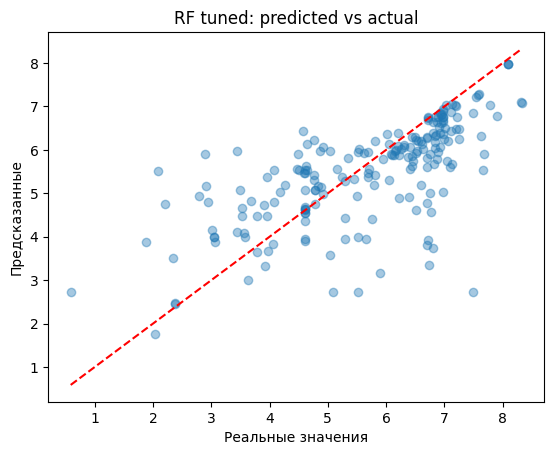

In [10]:
import matplotlib.pyplot as plt

best_pred = grid_rf.predict(X_test)

plt.scatter(y_test, best_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные')
plt.title('RF tuned: predicted vs actual')
plt.show()

CC50 предсказывается чуть хуже чем IC50. Разброс на высоких значениях большой. Lasso дал слабый результат из-за дефолтного alpha=1.0, слишком жёсткая регуляризация для этих данных. Для улучшения можно попробовать подобрать alpha через GridSearch.

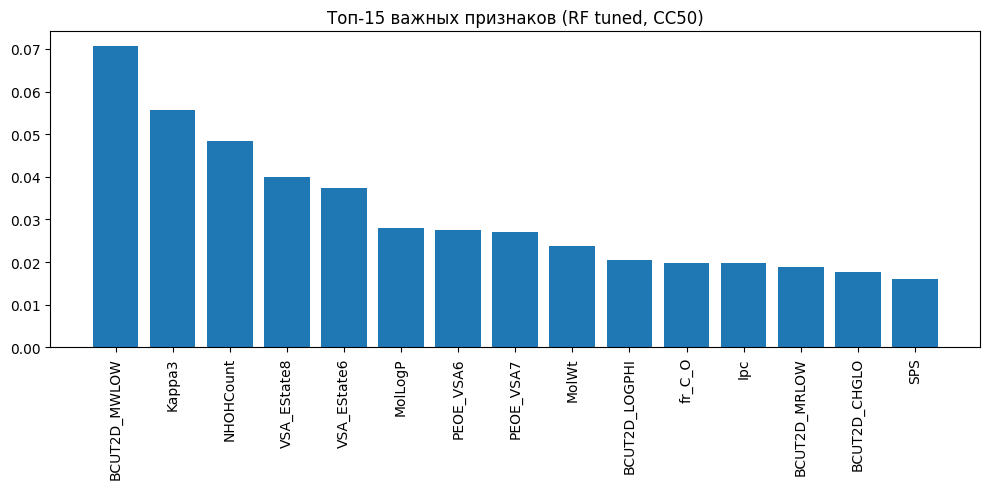

In [11]:
importances = grid_rf.best_estimator_.feature_importances_
feat_names = X.columns
top_idx = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10, 5))
plt.bar(range(15), importances[top_idx])
plt.xticks(range(15), feat_names[top_idx], rotation=90)
plt.title('Топ-15 важных признаков (RF tuned, CC50)')
plt.tight_layout()
plt.show()

Для CC50 важные признаки распределены равномернее чем для IC50, нет одного доминирующего дескриптора. В топ вошли BCUT2D_MWLOW (связан с молекулярным весом), Kappa3 (форма молекулы), NHOHCount (количество OH и NH групп). Это отличается от IC50, где доминирует VSA_EState8, можем сделать вывод, что у IC50 и CC50 разная молекулярная логика.